# Assignment 4 - Backmixing in tubular reactors

assumptions: isothermal, heat of reaction negligible -> only mass balance considered, rate constant not temperature dependent

\begin{align*}
    A \rightarrow B
\end{align*}

mass balance:

\begin{align*}
    \frac{dc_A}{d\tau}=-r
\end{align*}

\begin{align*}
    \frac{dc_B}{d\tau}=r
\end{align*}

first order:

r = k*c_A

\begin{align*}
    r=-\frac{dc_A}{d\tau}=-u\frac{dc_A}{dz}=k \cdot c_A
\end{align*}

\begin{align*}
    r=-\frac{dc_B}{d\tau}=u\frac{dc_B}{dz}
\end{align*}

## Motivation

In chemical reaction engineering ideal reactors like the CSTR (continuous stirred tank reactor) or the PFTR (Plug Flow Tubular Reactor) are often studied. However, these models underlie strong assumptions like no backmixing in the PFTR. In real reactors backmixing is a phenomen that has to be considered since it influences the conversion as well as the selectivity (Measurement and Simulation of Mass Transfer). There are two models to describe the flow behavior in a real reactor. These are the dispersion model with the Bodenstein number and the cascade model, where n CSTR's are connected in series.
In the following a tubular reactor with backmixing behavior is simulated. Following reaction is considered:

\begin{align*}
    A \rightarrow B
\end{align*}

## Implementation

In [119]:
import sys
import numpy as np
import scipy.integrate as integ #important for initial value problem
from scipy.integrate import solve_ivp
from scipy.integrate import solve_bvp
import matplotlib.pyplot as plt
import pandas as pd
from scipy.special import erf
from scipy.stats import gamma

In [120]:
#implement parameters

L = 10 #reactor length / m
d = 32 *10**-3 #reactor diameter / m
d_up = 150 * 10**(-3) # diameter upstream / m
V_dot = 1 # volumetric flow rate / m3/s
c_A_in = 100 # inlet concentration of component A / mol/m3
c_B_in = 0 # inlet concentration of component B / mol/m3
k = 1*10**3 # reaction rate constant / m3/mol/s

A = np.pi * (d/2)**2 #reactor diameter / m2
A_up = np.pi * (d_up/2)**2 #diameter upstream / m2

V_reactor = A * L # reactor volume / m3

tau = V_reactor / V_dot

theta = np.linspace(0.001, 3, 1000)   # dimensionless time theta = t/tau
t = theta * tau

u = V_dot / A                  # velocity in reactor / m/s
u_up = V_dot / A_up            # velocity upstream / m/s

# Boundary case: very large Bo -> nearly ideal PFTR
Bo = 10000
D_ax = u * L / Bo              # axial dispersion coefficient / m2/s

print("u =", u, "m/s")
print("D_ax =", D_ax, "m2/s")


def kinetics(c_A):
    r=k*c_A # reaction rate / mol/m3/s
    return r

u = 1243.3979929054324 m/s
D_ax = 1.2433979929054324 m2/s


### Ideal PFTR model - Initial value problem

At first the ideal PFTR is implemented. In this case it is assumed that there is no backmixing. From a mathematical perspective it is an initial value problem with the following initial value:

\begin{align*}
    c_{in}=c_0=100~mol~m^{-3}
\end{align*}

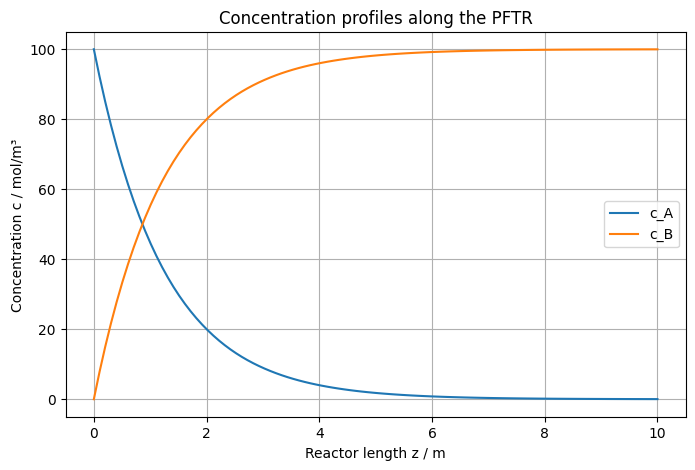

In [121]:
def PFTR_id(z, f):
    'ideal PFTR model'
    # f is a vector containing concentrations of components c_A (f[0]) and c_B (f[1])
    c_A = f[0]
    c_B = f[1]
    
    # reaction rate from kinetics function
    r = kinetics(c_A)
    
    # differential equations
    dc_A_dz = -r/u #change in concentration of A along the reactor length / mol/m^3/m
    dc_B_dz = r/u #change in concentration of B along the reactor length / mol/m^3/m
    
    dfdz = np.empty_like(f)
    dfdz[0] = dc_A_dz
    dfdz[1] = dc_B_dz
    return dfdz

# vector of initial conditions
f_init = np.array([c_A_in, 0]) #initial concentrations of A and B

# solve the system of ODEs using scipy's solve_ivp
tspan = (0, L) #span of the reactor length
zeval = np.linspace(0, L, 100) #points at which to evaluate the solution
sol_id = integ.solve_ivp(PFTR_id, tspan, f_init, t_eval=zeval)

# Plot concentration c over reactor length z

plt.figure(figsize=(8, 5))

plt.plot(sol_id.t, sol_id.y[0], label='c_A')
plt.plot(sol_id.t, sol_id.y[1], label='c_B')

plt.xlabel('Reactor length z / m')
plt.ylabel('Concentration c / mol/m³')
plt.title('Concentration profiles along the PFTR')
plt.grid(True)
plt.legend()
plt.show()

### Boundary Value Problem

For the PFTR with backmixing a boundary value problem has to be implemented. The mass balance can be written as follows:

$$
u \frac{\text{d}c_i}{\text{d}z} = \mathcal{D} \frac{\text{d}^2 c_i }{\text{d} z^2} + \sum_{j=1}^{M} \nu_{i,j} r_j
$$
In this case $u$ is the fluid velocity, $c_i$ the concentration of component i, $z$ the axial position in the reactor, $D$ the dispersion coefficient, $d$ the reactor diameter, $j$ the number of reactions, $\nu_{i,j}$ the stoichiometric coefficient of component i in reaction j and $r_j$ the rate of reaction j.
The diffusion coefficient $D$ results from different flow phenomena and thus different residence times of the single fluid elements. The higher the dispersion coefficieent, the wider is the residence time distribution.
For the boundary case D=0 the ideal case for a PFTR is obtained.

The Bodenstein number can be understood as the convective mass transfer compared to backmixing. It can be written as follows:

$$
Bo = \frac{u \, L}{\mathcal{D}}
$$

Assuming a bilaterally closed system, the Danckwerts boundary conditions can be written as follows:

\begin{align}
z &= 0: \qquad & u_0 A_0 c_{i0} &= u A c_i -A\mathcal{D} \frac{\text{d} c_i}{\text{d} z}\\
z &= L: \qquad & \frac{\text{d} c_i}{\text{d} z} &= 0
\end{align}

Here $u_0$ is the fluid velocity in the upstream section, $A_0$ the area of the upstream sectioon and $c_{i0} the concentration of component $i$ in the upstream section. A is the cross-sectional area of the tubular reactor.

The algorithm converged to the desired accuracy.


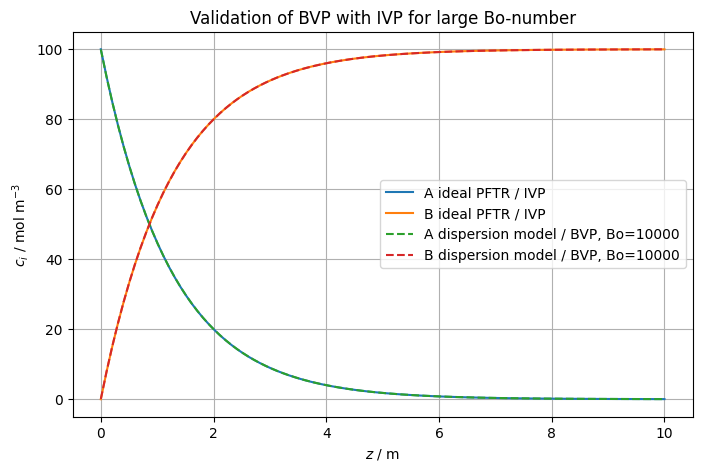

In [122]:
def PFTR_re(z, y):
    'real PFTR model with axial dispersion'
    c_A = y[0]
    dc_A_dz = y[1]
    c_B = y[2]
    dc_B_dz = y[3]
    
    r = kinetics(c_A)
    
    d2c_A_dz2 = (u * dc_A_dz + r) / D_ax
    d2c_B_dz2 = (u * dc_B_dz - r) / D_ax
    
    return np.vstack((dc_A_dz, d2c_A_dz2,
                      dc_B_dz, d2c_B_dz2))
    
def bc(ya, yb):
    'Danckwerts boundary conditions'
    # ya = values at z = 0
    # yb = values at z = L
    
    bc_A_in = u_up * A_up * c_A_in - (u * A * ya[0] - A * D_ax * ya[1])
    bc_B_in = u_up * A_up * c_B_in - (u * A * ya[2] - A * D_ax * ya[3])
    
    bc_A_out = yb[1]       # dcA/dz at z=L = 0
    bc_B_out = yb[3]       # dcB/dz at z=L = 0
    
    return np.array([bc_A_in, bc_B_in, bc_A_out, bc_B_out])

z = np.linspace(0, L, 200)

# Initial guess for BVP
y_init = np.zeros((4, z.size))
y_init[0] = c_A_in * np.exp(-k/u * z)       # guess for c_A
y_init[2] = c_A_in - y_init[0]              # guess for c_B

sol_re = solve_bvp(
    PFTR_re,
    bc,
    z,
    y_init,
    max_nodes=10000
)

print(sol_re.message)

plt.figure(figsize=(8,5))

plt.plot(sol_id.t, sol_id.y[0], label="A ideal PFTR / IVP")
plt.plot(sol_id.t, sol_id.y[1], label="B ideal PFTR / IVP")

plt.plot(sol_re.x, sol_re.y[0], "--", label=f"A dispersion model / BVP, Bo={Bo}")
plt.plot(sol_re.x, sol_re.y[2], "--", label=f"B dispersion model / BVP, Bo={Bo}")

plt.xlabel("$z$ / m")
plt.ylabel("$c_i$ / mol m$^{-3}$")
plt.title("Validation of BVP with IVP for large Bo-number")
plt.grid(True)
plt.legend()
plt.show()

The curves for the concentrations of the components A and B are characteristic for an ideal PFTR. For a large Bo number and thus very low dispersion coefficient, the curves for the ideal PFTR and the dispersion model are very  close to each other.

### Task 2

In the following the influence of backmixing is investigated for different Bo numers and thus different degrees of dispersion. 

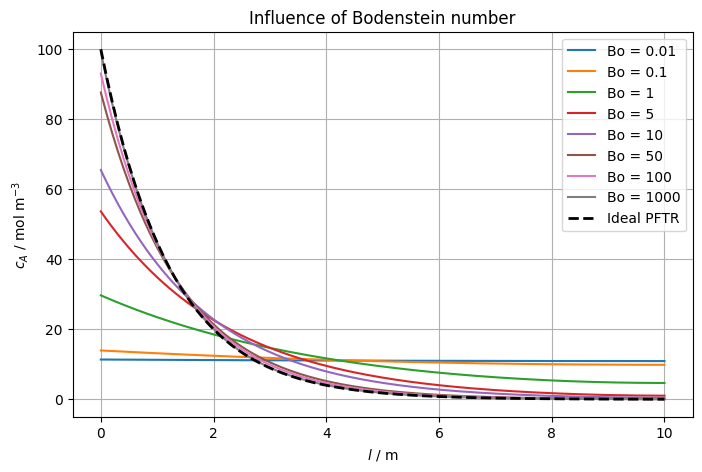

In [123]:
Bo_list = [0.01, 0.1, 1, 5, 10, 50, 100, 1000]

plt.figure(figsize=(8,5))

for Bo in Bo_list:

    D_ax = u * L / Bo

    sol_re = solve_bvp(
        PFTR_re,
        bc,
        z,
        y_init,
        max_nodes=10000
    )

    plt.plot(sol_re.x,
             sol_re.y[0],
             label=f"Bo = {Bo}")
    
plt.plot(sol_id.t,
         sol_id.y[0],
         "k--",
         linewidth=2,
         label="Ideal PFTR")

plt.xlabel("$l$ / m")
plt.ylabel("$c_A$ / mol m$^{-3}$")
plt.title("Influence of Bodenstein number")
plt.grid(True)
plt.legend()
plt.show()

For an ideal PFTR the initial concentration is the starting concentration of component A. It decreases with the reactor length as already discussed in task 1 and assignment 3. The higher the Bo-numbers, the more ideal is the tubular reactor and the influence of backmixing decreases. For Bo $\rightarrow$ $\infty$ the reactor shows the behavior of an ideal PFTR. For low Bo-numbers backmixing has a big impact on the concentration course. Through the high dispersion the initial concentration in the reactor is smaller than the concentration in the upstream section. For very low Bo-numbers (Bo $\rightarrow$ 0) the curve is very flat and the reactor shows the behavior of an ideal CSTR.

### Task 3: CSTR cascade

The flow behavior in a reactor can also be explained with a cascade model, in which a number of CSTR is connected in series. 

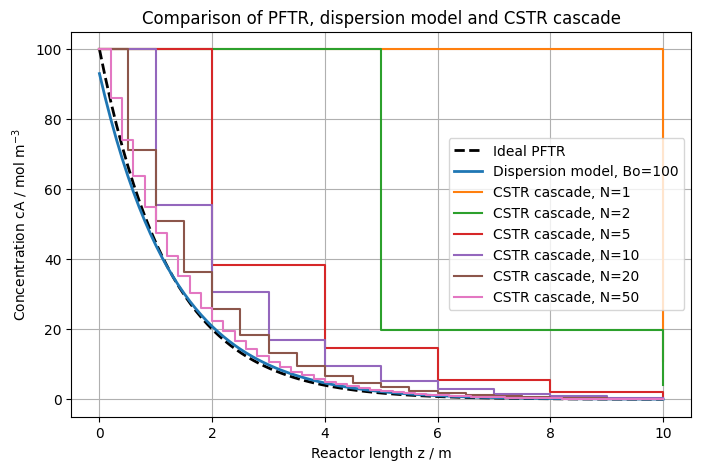

In [124]:
def CSTR_cascade(N):
    
    tau_total = V_reactor / V_dot
    tau_i = tau_total / N
    
    c_A_values = [c_A_in]
    c_B_values = [c_B_in]
    z_values = [0]
    
    c_A_current = c_A_in
    c_B_current = c_B_in
    
    for i in range(N):
        
        # ideal CSTR balance for first-order reaction
        c_A_out = c_A_current / (1 + k * tau_i)
        
        # stoichiometry: A -> B
        c_B_out = c_B_current + (c_A_current - c_A_out)
        
        c_A_values.append(c_A_out)
        c_B_values.append(c_B_out)
        
        z_values.append((i+1) * L / N)
        
        c_A_current = c_A_out
        c_B_current = c_B_out
    
    return np.array(z_values), np.array(c_A_values), np.array(c_B_values)

N_list = [1, 2, 5, 10, 20, 50]

plt.figure(figsize=(8,5))

# ideal PFTR
plt.plot(sol_id.t,
         sol_id.y[0],
         "k--",
         linewidth=2,
         label="Ideal PFTR")

# dispersion model, choose one Bo for comparison
Bo = 100
D_ax = u * L / Bo

sol_re = solve_bvp(
    PFTR_re,
    bc,
    z,
    y_init,
    max_nodes=10000
)

plt.plot(sol_re.x,
         sol_re.y[0],
         linewidth=2,
         label=f"Dispersion model, Bo={Bo}")

# CSTR cascades
for N in N_list:
    
    z_cstr, c_A_cstr, c_B_cstr = CSTR_cascade(N)
    
    plt.step(z_cstr,
             c_A_cstr,
             where="post",
             label=f"CSTR cascade, N={N}")

plt.xlabel("Reactor length z / m")
plt.ylabel("Concentration cA / mol m$^{-3}$")
plt.title("Comparison of PFTR, dispersion model and CSTR cascade")
plt.grid(True)
plt.legend()
plt.show()

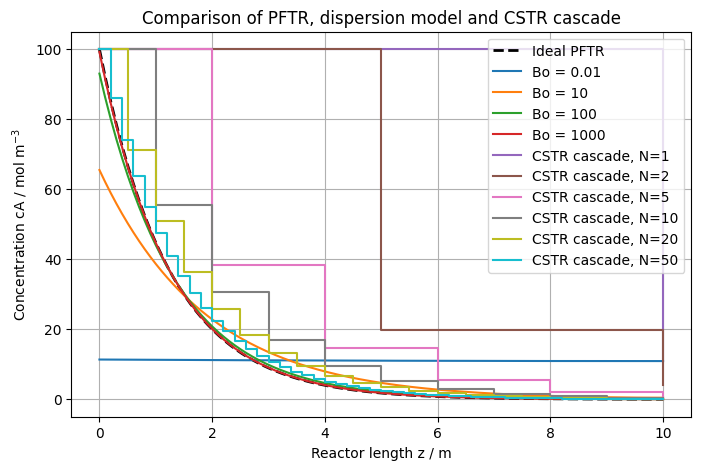

In [125]:
def CSTR_cascade(N):
    
    tau_total = V_reactor / V_dot
    tau_i = tau_total / N
    
    c_A_values = [c_A_in]
    c_B_values = [c_B_in]
    z_values = [0]
    
    c_A_current = c_A_in
    c_B_current = c_B_in
    
    for i in range(N):
        
        # ideal CSTR balance for first-order reaction
        c_A_out = c_A_current / (1 + k * tau_i)
        
        # stoichiometry: A -> B
        c_B_out = c_B_current + (c_A_current - c_A_out)
        
        c_A_values.append(c_A_out)
        c_B_values.append(c_B_out)
        
        z_values.append((i+1) * L / N)
        
        c_A_current = c_A_out
        c_B_current = c_B_out
    
    return np.array(z_values), np.array(c_A_values), np.array(c_B_values)

Bo_list = [0.01, 10, 100, 1000]

N_list = [1, 2, 5, 10, 20, 50]

plt.figure(figsize=(8,5))

# ideal PFTR
plt.plot(sol_id.t,
         sol_id.y[0],
         "k--",
         linewidth=2,
         label="Ideal PFTR")

# dispersion model, choose one Bo for comparison

for Bo in Bo_list:

    D_ax = u * L / Bo

    sol_re = solve_bvp(
        PFTR_re,
        bc,
        z,
        y_init,
        max_nodes=10000
    )

    plt.plot(sol_re.x,
             sol_re.y[0],
             label=f"Bo = {Bo}")

# CSTR cascades
for N in N_list:
    
    z_cstr, c_A_cstr, c_B_cstr = CSTR_cascade(N)
    
    plt.step(z_cstr,
             c_A_cstr,
             where="post",
             label=f"CSTR cascade, N={N}")

plt.xlabel("Reactor length z / m")
plt.ylabel("Concentration cA / mol m$^{-3}$")
plt.title("Comparison of PFTR, dispersion model and CSTR cascade")
plt.grid(True)
plt.legend()
plt.show()

In the plot there are different concentration curves for different cases given. The black line shows the concentration curve for an ideal PFTR. For high Bo-numbers the concentration curves is closer to the line for the ideal PFTR because the backmixing is less dominant. Taking a closer look at the cascade model, für N = 1 the concentration curve corresponds to the one of an ideal CSTR and the concentration of component A jumps to the value at the reactor outlet. For a low number of cascades the concentration jumps are pretty high and decrease with a higher reactor length. The higher the number of cascades, the more continuous is the concentrationn profile. For n = 50 and Bo = 100 the curves approach each other, which was also mentioned in Güttel and Turek (2021), and the reactor can be assumed to be ideal.

The comparision shows the impact of the different models on the concentration curves. While the dispersion model is continuous, the cascade model shows a stepwise change in the concentration profile since backmixing occurs only between two CSTRs and not within a CSTR. 

The cascade model is a good approach to investigate the residence time distribution in a real plug flow reactor, but can only be used for integer values for N and not for N < 1. 

### 2nd order reaction - Ideal PFTR Model

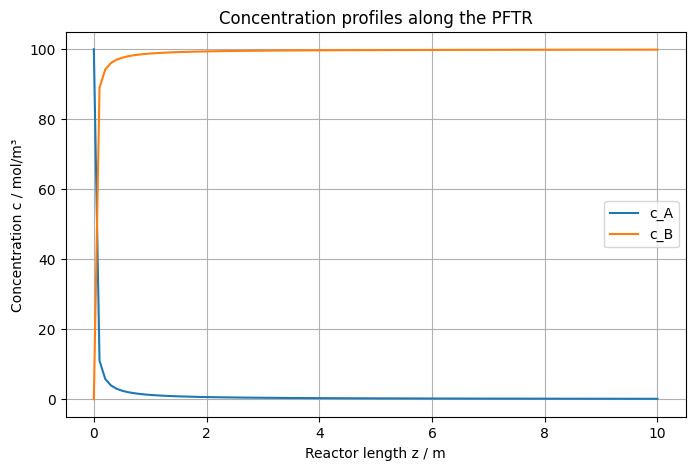

In [126]:
def kinetics(c_A):
    r=k*c_A**2 # reaction rate / mol/m3/s
    return r

def PFTR_id(z, f):
    'ideal PFTR model'
    # f is a vector containing concentrations of components c_A (f[0]) and c_B (f[1])
    c_A = f[0]
    c_B = f[1]
    
    # reaction rate from kinetics function
    r = kinetics(c_A)
    
    # differential equations
    dc_A_dz = -r/u #change in concentration of A along the reactor length / mol/m^3/m
    dc_B_dz = r/u #change in concentration of B along the reactor length / mol/m^3/m
    
    dfdz = np.empty_like(f)
    dfdz[0] = dc_A_dz
    dfdz[1] = dc_B_dz
    return dfdz

# vector of initial conditions
f_init = np.array([c_A_in, 0]) #initial concentrations of A and B

# solve the system of ODEs using scipy's solve_ivp
tspan = (0, L) #span of the reactor length
zeval = np.linspace(0, L, 100) #points at which to evaluate the solution
sol_id = integ.solve_ivp(PFTR_id, tspan, f_init, t_eval=zeval)

# Plot concentration c over reactor length z

plt.figure(figsize=(8, 5))

plt.plot(sol_id.t, sol_id.y[0], label='c_A')
plt.plot(sol_id.t, sol_id.y[1], label='c_B')

plt.xlabel('Reactor length z / m')
plt.ylabel('Concentration c / mol/m³')
plt.title('Concentration profiles along the PFTR')
plt.grid(True)
plt.legend()
plt.show()

### 2nd order reaction - boundary value problem

The algorithm converged to the desired accuracy.


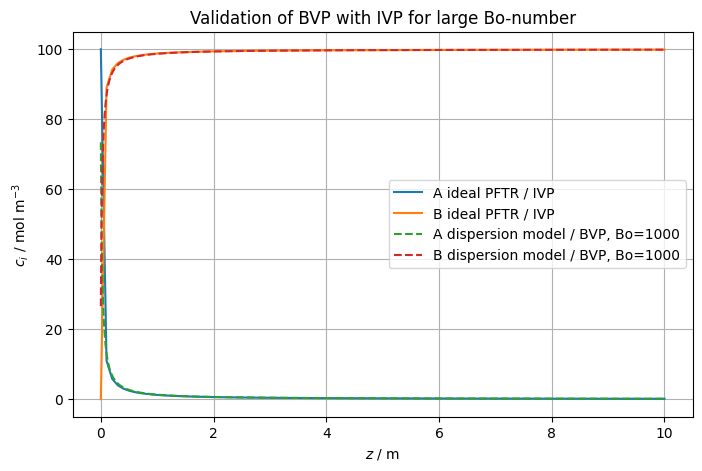

In [127]:
def PFTR_re(z, y):
    'real PFTR model with axial dispersion'
    c_A = y[0]
    dc_A_dz = y[1]
    c_B = y[2]
    dc_B_dz = y[3]
    
    r = kinetics(c_A)
    
    d2c_A_dz2 = (u * dc_A_dz + r) / D_ax
    d2c_B_dz2 = (u * dc_B_dz - r) / D_ax
    
    return np.vstack((dc_A_dz, d2c_A_dz2,
                      dc_B_dz, d2c_B_dz2))
    
def bc(ya, yb):
    'Danckwerts boundary conditions'
    # ya = values at z = 0
    # yb = values at z = L
    
    bc_A_in = u_up * A_up * c_A_in - (u * A * ya[0] - A * D_ax * ya[1])
    bc_B_in = u_up * A_up * c_B_in - (u * A * ya[2] - A * D_ax * ya[3])
    
    bc_A_out = yb[1]       # dcA/dz at z=L = 0
    bc_B_out = yb[3]       # dcB/dz at z=L = 0
    
    return np.array([bc_A_in, bc_B_in, bc_A_out, bc_B_out])

z = np.linspace(0, L, 1000)

# Initial guess for BVP
y_init = np.zeros((4, z.size))
y_init[0] = c_A_in * np.exp(-k/u * z)       # guess for c_A
y_init[2] = c_A_in - y_init[0]              # guess for c_B

sol_re = solve_bvp(
    PFTR_re,
    bc,
    z,
    y_init,
    max_nodes=10000
)

print(sol_re.message)

plt.figure(figsize=(8,5))

plt.plot(sol_id.t, sol_id.y[0], label="A ideal PFTR / IVP")
plt.plot(sol_id.t, sol_id.y[1], label="B ideal PFTR / IVP")

plt.plot(sol_re.x, sol_re.y[0], "--", label=f"A dispersion model / BVP, Bo={Bo}")
plt.plot(sol_re.x, sol_re.y[2], "--", label=f"B dispersion model / BVP, Bo={Bo}")

plt.xlabel("$z$ / m")
plt.ylabel("$c_i$ / mol m$^{-3}$")
plt.title("Validation of BVP with IVP for large Bo-number")
plt.grid(True)
plt.legend()
plt.show()

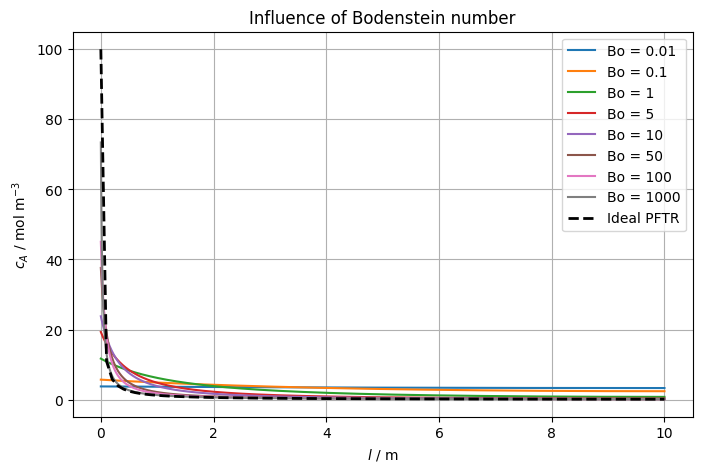

In [128]:
Bo_list = [0.01, 0.1, 1, 5, 10, 50, 100, 1000]

plt.figure(figsize=(8,5))

for Bo in Bo_list:

    D_ax = u * L / Bo

    sol_re = solve_bvp(
        PFTR_re,
        bc,
        z,
        y_init,
        max_nodes=10000
    )

    plt.plot(sol_re.x,
             sol_re.y[0],
             label=f"Bo = {Bo}")
    
plt.plot(sol_id.t,
         sol_id.y[0],
         "k--",
         linewidth=2,
         label="Ideal PFTR")

plt.xlabel("$l$ / m")
plt.ylabel("$c_A$ / mol m$^{-3}$")
plt.title("Influence of Bodenstein number")
plt.grid(True)
plt.legend()
plt.show()